# 04 — Model Comparison and Threshold Optimization

Compares candidate models on the realistic feature set (no `duration`) using cross-validation
plus a held-out test set, then tunes the decision threshold — properly, on a validation split,
not on the test set the metrics are reported on.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.data_loader import load_bank_data
from src.preprocessing import split_features_target
from src.modeling import build_pipeline, candidate_models
from src.model_comparison import compare_models, compute_metrics, optimize_threshold
from src.config import RANDOM_STATE, TEST_SIZE, VALIDATION_SIZE

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

raw_df = load_bank_data()

## Cross-validated comparison

Each candidate gets 5-fold CV on the training split (to see variance across folds) and then one evaluation on the held-out test split.

In [2]:
results = compare_models(raw_df)
comparison = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
comparison.round(4)

,accuracy,precision,recall,f1,roc_auc,average_precision,cv_roc_auc_mean,cv_roc_auc_std,cv_average_precision_mean
gradient_boosting,0.9006,0.6518,0.2522,0.3636,0.8133,0.4920,0.7999,0.0068,0.4647
random_forest,0.9000,0.6503,0.2425,0.3532,0.8054,0.4857,0.7941,0.0085,0.4657
logistic_regression,0.8983,0.6500,0.2101,0.3176,0.8004,0.4541,0.7898,0.0072,0.4515
decision_tree,0.9000,0.6538,0.2381,0.3491,0.7989,0.4372,0.7769,0.0083,0.4140


`gradient_boosting` (HistGradientBoostingClassifier) has the best test ROC-AUC and average precision, with a CV standard deviation similar to the other models — its improvement isn't an artifact of one lucky split. That's the model `src/final_pipeline.py` uses for the production artifact.

## Threshold tuning — on a validation split, not the test set

The default 0.5 threshold assumes false positives and false negatives cost the same, which isn't true for campaign targeting: at 0.5 the best model's recall was as low as 25% (see `reports/metrics.json`, `test_metrics_at_0.5`) — it misses 3 out of 4 actual subscribers. Sweeping thresholds to maximize F1 needs its own held-out data: tuning on the same test set used for the final report would let the threshold overfit to that particular 20% of rows and overstate performance.

In [3]:
X, y = split_features_target(raw_df)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE, stratify=y_trainval,
)

best_model = build_pipeline(candidate_models()['gradient_boosting'], X_train)
best_model.fit(X_train, y_train)
val_probs = best_model.predict_proba(X_val)[:, 1]

threshold, threshold_metrics = optimize_threshold(y_val, val_probs)
print('Best threshold by F1 (chosen on validation):', round(threshold, 3))
print(threshold_metrics)

Best threshold by F1 (chosen on validation): 0.25
{'accuracy': 0.8835761991499697, 'precision': 0.48484848484848486, 'recall': 0.5390835579514824, 'f1': 0.5105296745373324, 'roc_auc': 0.8167059421836111, 'average_precision': 0.4702513335223789, 'threshold': np.float64(0.24999999999999994)}


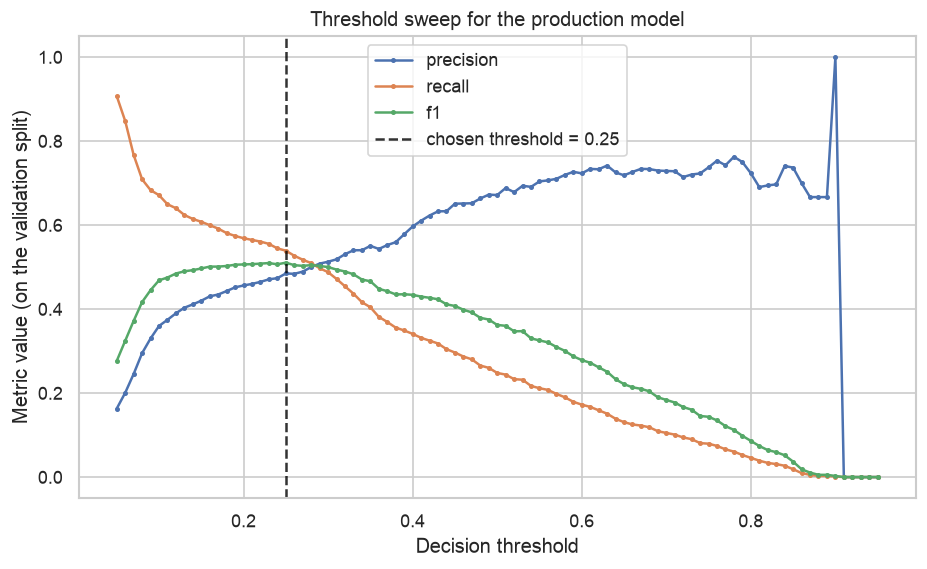

In [4]:
thresholds = np.linspace(0.05, 0.95, 91)
rows = [compute_metrics(y_val, val_probs, threshold=t) | {'threshold': t} for t in thresholds]
sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))
for metric in ['precision', 'recall', 'f1']:
    ax.plot(sweep['threshold'], sweep[metric], label=metric, marker='o', markersize=2)
ax.axvline(threshold, color='black', linestyle='--', alpha=0.8, label=f'chosen threshold = {threshold:.2f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Metric value (on the validation split)')
ax.set_title('Threshold sweep for the production model')
ax.legend()
plt.show()

## Confirming on the test set

This is the one and only look at the test set for this threshold — used to report the number, not to pick it.

In [5]:
final_model = build_pipeline(candidate_models()['gradient_boosting'], X_trainval)
final_model.fit(X_trainval, y_trainval)
test_probs = final_model.predict_proba(X_test)[:, 1]
print('Test metrics at the validation-chosen threshold:')
for name, value in compute_metrics(y_test, test_probs, threshold=threshold).items():
    print(f'  {name:20} {value:.4f}')

Test metrics at the validation-chosen threshold:
  accuracy             0.8832
  precision            0.4845
  recall               0.5722
  f1                   0.5247
  roc_auc              0.8133
  average_precision    0.4920


## A note on the random split

Notebook 02 found that `month` and the economic indicators trace the same shifting macro timeline, and the file is contact-ordered. A quick sanity check: train on the first 80% of rows in file order, test on the last 20%, and compare to the random split above.

In [6]:
cut = int(len(X) * 0.8)
temporal_model = build_pipeline(candidate_models()['gradient_boosting'], X.iloc[:cut])
temporal_model.fit(X.iloc[:cut], y.iloc[:cut])
temporal_probs = temporal_model.predict_proba(X.iloc[cut:])[:, 1]
print('Base rate — first 80% of rows:', round(y.iloc[:cut].mean(), 3), '| last 20%:', round(y.iloc[cut:].mean(), 3))
print('Temporal-split test ROC-AUC:', round(compute_metrics(y.iloc[cut:], temporal_probs)['roc_auc'], 4))
print('(Random-split test ROC-AUC was', round(compute_metrics(y_test, test_probs)['roc_auc'], 4), 'above)')

Base rate — first 80% of rows: 0.064 | last 20%: 0.308
Temporal-split test ROC-AUC: 0.6334
(Random-split test ROC-AUC was 0.8133 above)


ROC-AUC drops sharply under the temporal split — from 0.81 (random split) to 0.63 — and the base rate itself nearly quintuples between the two periods (6.4% in the first 80% of rows vs. 30.8% in the last 20%). That's not a subtle effect: it means a model trained purely on the earlier, high-volume/low-conversion period generalizes poorly to the later period's very different conditions.

The random 80/20 split used everywhere else in this project (and reported in `reports/metrics.json`) mixes both periods into both train and test, which is standard practice and gives an honest estimate *for data drawn from the same mixture of regimes*. It does not certify the model against a genuinely new regime the training data never saw. In production this means: monitor performance whenever `models/economic_snapshots.json`'s indicators drift materially from the training ranges, and retrain on a rolling window rather than treating one static model as permanent.